##### Linear Discriminant Analysis

In [1]:
# Implementation of LDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
#load dataset
iris=load_iris()
dataset=pd.DataFrame(columns=iris.feature_names,
                    data=iris.data)
dataset['target']=iris.target
X= dataset.iloc[:,0:4].values
y= dataset.iloc[:,4].values

In [3]:
# Standardize the dataset for input feature
sc= StandardScaler()
X= sc.fit_transform(X)

#categorize the value for output feature
le= LabelEncoder()
y=le.fit_transform(y)

In [4]:
#split the dataset
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2)

In [5]:
#create the model
lda= LinearDiscriminantAnalysis(n_components=2)
X_train=lda.fit_transform(X_train,y_train)
X_test= lda.transform(X_test)

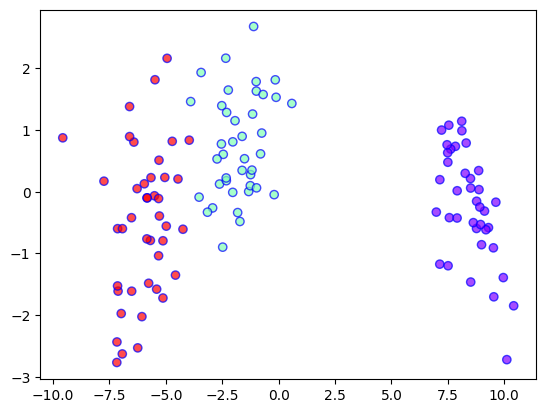

In [6]:
#create scatter plot
plt.scatter(X_train[:,0], X_train[:,1], 
            c=y_train, cmap='rainbow',
            alpha=0.7, edgecolor='b')

In [7]:
# use Random classifier
randomclass=RandomForestClassifier(max_depth=2,
                                  random_state=0)
randomclass.fit(X_train,y_train)
y_pred= randomclass.predict(X_test)
# print accuracy
print('Accuracy:', str(
    accuracy_score(y_test,y_pred)))
# print confusion matric=x
conf_m=confusion_matrix(y_test,y_pred)
print(conf_m)

Accuracy: 0.9
[[11  1  0]
 [ 0  8  2]
 [ 0  0  8]]
